# 1

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import eig, inv, expm
# Constants (all = 1)
k = 1
m = 1
M = 1
l = 1
g = 1

# System matrix A
A = np.array([
    [0, 1, 0, 0],
    [-k/M, 0, m*g/M, 0],
    [0, 0, 0, 1],
    [0, 0, (m*g + M*g)/(M*l), 0]
], dtype=float)

In [2]:
eigenvalues, Q = eig(A)
D = np.diag(eigenvalues)
Qinv = inv(Q)

print("Eigenvalues:")
print(eigenvalues)

print("\nEigenvector matrix Q:")
print(Q)

print("\nDiagonal matrix D:")
print(D)

Eigenvalues:
[ 0.        +1.j  0.        -1.j  1.41421356+0.j -1.41421356+0.j]

Eigenvector matrix Q:
[[ 0.70710678+0.j          0.70710678-0.j          0.18257419+0.j
  -0.18257419+0.j        ]
 [ 0.        +0.70710678j  0.        -0.70710678j  0.25819889+0.j
   0.25819889+0.j        ]
 [ 0.        +0.j          0.        -0.j          0.54772256+0.j
  -0.54772256+0.j        ]
 [ 0.        +0.j          0.        -0.j          0.77459667+0.j
   0.77459667+0.j        ]]

Diagonal matrix D:
[[ 0.        +1.j  0.        +0.j  0.        +0.j  0.        +0.j]
 [ 0.        +0.j  0.        -1.j  0.        +0.j  0.        +0.j]
 [ 0.        +0.j  0.        +0.j  1.41421356+0.j  0.        +0.j]
 [ 0.        +0.j  0.        +0.j  0.        +0.j -1.41421356+0.j]]


# 1b

In [3]:
# MODAL Coordinates = Q^-1 * x
x0 = np.array([1, 0, 0, 0], dtype=float)
w0 = Qinv @ x0

print("Modal coordinates w(0):")
print(w0)

Modal coordinates w(0):
[0.70710678+0.j 0.70710678+0.j 0.        +0.j 0.        +0.j]


# 1c

We diagonalize the system $A = QDQ^{-1}$ so the change of variables $x=Qw$, where $w$ are the modal coordinates, turns the linear system $ \dot{x} = Ax$ into a system of decoupled scalar ODEs:$\dot{w_i} = \lambda_i w_i$ where D is a diagonal matrix with diagonal: $[\lambda_1 \lambda_2 \dots \lambda_n]$. 
Each mode thus evolves independantly as $w_i(t) = w_i(0) e^{\lambda_i t}$.
Per $w(0)$, notice that only the first 2 modes are activate, at equal magnitudes. We have $w(t) = [w1(t) = .7071 e^{it}; w2(t) = .7071 e^{-it};w3(t) = 0; w4(t) =0  ]$. Per Euler's formula, the solution is a combination of $cos(t)$ and $sin(t)$ meaning the motion is purely oscillatory for the position $p_x$ and the position's derivative $\dot{p}_x$. Notice that $w3(t) = w4(t) = 0$ so the last two modes are  not activeted; thus the pole angle remains near zero (up to roundoff error) since the oscillatory eigenvectors have 0 component in the $\theta$  direction.

/home/mili/miniconda3/envs/cs/lib/python3.11/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/mili/miniconda3/envs/cs/lib/python3.11/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


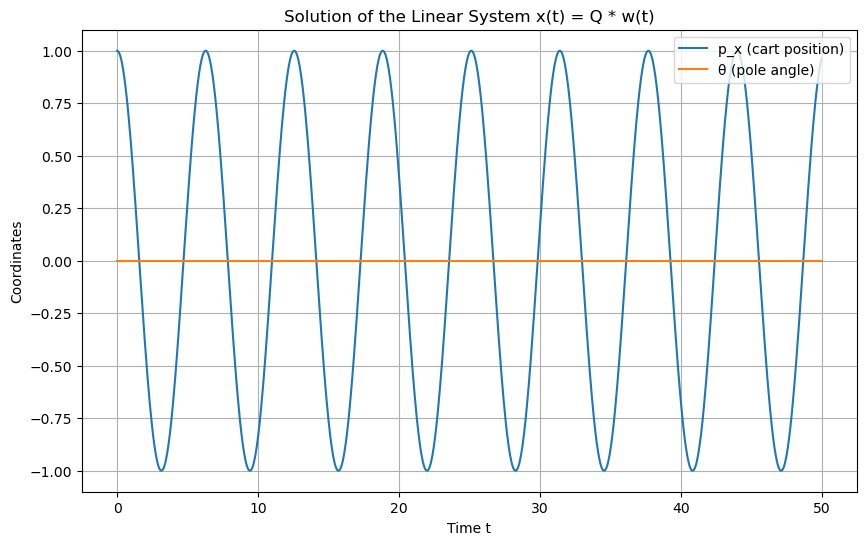

In [4]:
# Time vector
t = np.linspace(0, 50, 1000)

# Modal solutions
w1_t = w0[0] * np.exp(eigenvalues[0] * t)
w2_t = w0[1] * np.exp(eigenvalues[1] * t)
w3_t = w0[2] * np.exp(eigenvalues[2] * t)
w4_t = w0[3] * np.exp(eigenvalues[3] * t)

# Stack modal solutions
w_t = np.array([w1_t, w2_t, w3_t, w4_t])

# Transform back to original coordinates: x(t) = Q * w(t)
x_t = Q @ w_t

# Plot
plt.figure(figsize=(10, 6))
plt.plot(t, x_t[0, :], label='p_x (cart position)')
plt.plot(t, x_t[2, :], label='θ (pole angle)')
plt.xlabel('Time t')
plt.ylabel('Coordinates')
plt.title('Solution of the Linear System x(t) = Q * w(t)')
plt.legend()
plt.grid(True)
plt.show()

# 1d

For the initial condition $\mathbf{x}(0) = (0.0913, 0.1291, 0.2739, 0.3873)^\top$, the modal coordinates are given by $\mathbf{w}(0) = \mathbf{Q}^{-1}\mathbf{x}(0)$. Unlike the previous case where only the oscillatory modes were activated, this initial condition excites all four modes of the system. The solution can be expressed as $\mathbf{x}(t) = \mathbf{Q} \mathbf{w}(t)$, where each modal coordinate evolves independently as $w_i(t) = w_i(0)e^{\lambda_i t}$. With eigenvalues $\lambda_{1,2} = \pm i$ (purely oscillatory) and $\lambda_{3,4} = \pm \sqrt{2}$ (real, with one positive and one negative), the system response will exhibit both oscillatory and exponential behavior. The presence of the positive real eigenvalue $\lambda_3 = \sqrt{2} > 0$ indicates that the system is unstable for this initial condition. Consequently, while the cart position $p_x(t)$ and pole angle $\theta(t)$ will initially display slight oscillatory components from the first two modes, the unstable mode will eventually dominate, causing both coordinates to grow exponentially in magnitude. This means the pole will fall over and the cart will move away from its initial position; this is quite different from the purely oscillatory, bounded motion observed when only the imaginary eigenvalues were excited.

Also, the third modal coordinate evolves as $w_3(t) = w_3(0)e^{\sqrt{2}t}$ grows without bound as $t \to \infty$. Examining the eigenvector matrix $\mathbf{Q}$, the third column (corresponding to $\lambda_3$) has non-zero components in both the cart position and pole angle coordinates. Specifically, from the eigenvector structure, we can see that $w_3(0) \neq 0$ contributes directly to both $p_x(t)$ and $\theta(t)$ through the transformation $\mathbf{x}(t) = \mathbf{Q}\mathbf{w}(t)$. Since this unstable mode grows exponentially and couples into the pole angle coordinate, $\theta(t)$ inherits this unbounded growth. 



Eigenvalues:
[ 0.        +1.j  0.        -1.j  1.41421356+0.j -1.41421356+0.j]

Modal coordinates w(0) = Q^(-1) * x(0):
[ 2.68440417e-17-1.82734467e-17j  2.68440417e-17+1.82734467e-17j
  5.00036422e-01+0.00000000e+00j -3.42725034e-05+0.00000000e+00j]


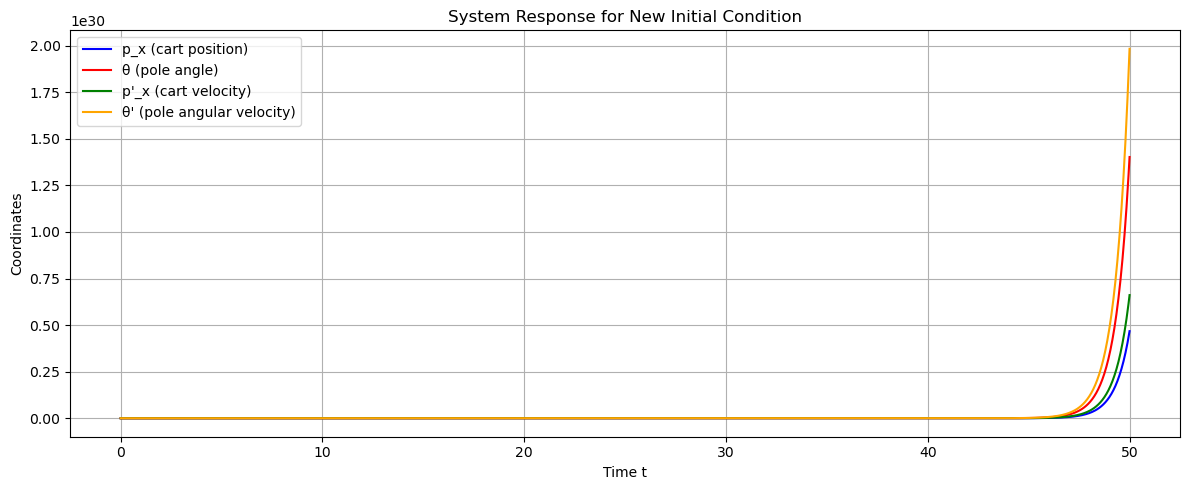


ANALYSIS OF THE MOTION

Magnitudes of modal coordinates: [0.  0.  0.5 0. ]
Active modes: [2 3]

Mode characteristics:
Mode 1: λ = 0.0000+1.0000j, |w1(0)| = 0.0000 (oscillatory)
Mode 2: λ = 0.0000-1.0000j, |w2(0)| = 0.0000 (oscillatory)
Mode 3: λ = 1.4142+0.0000j, |w3(0)| = 0.5000 (exponential)
Mode 4: λ = -1.4142+0.0000j, |w4(0)| = 0.0000 (exponential)


In [6]:
x0_new = np.array([0.0913, 0.1291, 0.2739, 0.3873], dtype=float)

w0_new = Qinv @ x0_new

print("\nEigenvalues:")
print(eigenvalues)
print("\nModal coordinates w(0) = Q^(-1) * x(0):")
print(w0_new)



# Modal solutions
w1_t = w0_new[0] * np.exp(eigenvalues[0] * t)
w2_t = w0_new[1] * np.exp(eigenvalues[1] * t)
w3_t = w0_new[2] * np.exp(eigenvalues[2] * t)
w4_t = w0_new[3] * np.exp(eigenvalues[3] * t)

# Stack modal solutions
w_t = np.array([w1_t, w2_t, w3_t, w4_t])

# Transform back to original coordinates: x(t) = Q * w(t)
x_t = Q @ w_t

# Plot
plt.figure(figsize=(12, 5))

plt.plot(t, np.real(x_t[0, :]), 'b-', label='p_x (cart position)')
plt.plot(t, np.real(x_t[2, :]), 'r-', label='θ (pole angle)')
plt.plot(t, np.real(x_t[1, :]), 'g-', label='p\'_x (cart velocity)')
plt.plot(t, np.real(x_t[3, :]), 'orange', label='θ\' (pole angular velocity)')
plt.xlabel('Time t')
plt.ylabel('Coordinates')
plt.title('System Response for New Initial Condition')
plt.legend()
plt.grid(True)



plt.tight_layout()
plt.show()

# Print analysis
print("\n" + "=" * 60)
print("ANALYSIS OF THE MOTION")
print("=" * 60)

# Calculate magnitudes of modal coordinates
mag_w0 = np.abs(w0_new)
print(f"\nMagnitudes of modal coordinates: {np.round(mag_w0, 4)}")

# Determine which modes are active
active_modes = np.where(mag_w0 > 1e-10)[0]
print(f"Active modes: {active_modes}")

# Check if modes are oscillatory or exponential
print("\nMode characteristics:")
for i, eig in enumerate(eigenvalues):
    mode_type = "oscillatory" if np.abs(np.imag(eig)) > 1e-10 else "exponential"
    print(f"Mode {i+1}: λ = {eig:.4f}, |w{i+1}(0)| = {mag_w0[i]:.4f} ({mode_type})")